# README


In [2]:
from __future__ import annotations

import io
import logging
from pathlib import Path
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

from IPython.display import display
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.model_selection import TimeSeriesSplit

In [6]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    force=True,
)
LOGGER = logging.getLogger("phase0_pipeline")
CONFIG = {
    "universe_source_url": "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies",
    "start_date": "2015-01-01",
    "end_date": "2026-01-01",
    "momentum_lookback_days": 252,
    "momentum_skip_days": 21,
    "mean_reversion_lookback_days": 5,
    "volatility_lookback_days": 20,
    "forward_return_days": 5,
    "min_cross_section": 20,
    "cv_splits": 5,
    "min_train_days": 60,
    "ridge_alphas": np.logspace(-4, 4, 25),
    "top_quantile": 0.10,
    "bottom_quantile": 0.10,
    "risk_free_rate": 0.0,
    "annualization": 252,
    "data_dir": Path("data"),
    "ohlcv_path": Path("data/ohlcv.parquet"),
    "factor_panel_path": Path("data/factor_panel.parquet"),

}

# Data

# Limitation
- Survisorship bias: The initial dataset uses the current S&P 500 constituents (crawled from Wikipedia) and therefore contains survivorship bias.
- Globally defined valid data: the current data requires "["open", "low", "high", "close", "adj_close", "volume"]" to all exists, and in the cleaning step, removing all the rows lacking values of one of these fields. But this is problematic if the factors we are concerned with do not need all those values (e.g., momentum only needs "adjusted_close", so if "volume = NaN", it is fine, but our cleaning step will aggresivelly remove rows with "volume = NaN")
- The report in the cleaning step should be returned like a "dict", or "json", rather than simply "LOGGER"
- Need validation tests, like
""" python
assert panel.index.names == ["date", "ticker"]
assert panel.index.is_monotonic_increasing
assert panel["adj_close"].ge(0).all()
assert panel["volume"].ge(0).all()
assert panel.index.get_level_values("ticker").nunique() > 400
"""

In [7]:
def ensure_data_directory(path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)

def save_parquet(df: pd.DataFrame, path: Path) -> None:
    ensure_data_directory(path)
    df.to_parquet(path)
    LOGGER.info("Saved DataFrame to %s", path)
    
def load_parquet(path: Path) -> None:
    LOGGER.info("Loading DataFrame from %s", path)
    return pd.read_parquet(path)

class TickerCreator:
    def __init__(self, url:str):
        self._url = url

    def _read_html_tables(self) -> list[pd.DataFrame]:
        request = Request(
            self._url,
            headers = {
                "User-Agent": (
                    "Mozilla/5.0 (X11; Linux x86_64) "
                    "AppleWebKit/537.36 (KHTML, like Gecko) "
                    "Chrome/124.0 Safari/537.36"
                )
             },
        )
        with urlopen(request, timeout = 30) as response:
            html = response.read().decode("utf-8", errors="ignore")

        tables = pd.read_html(io.StringIO(html))
        if not tables:
            raise ValueError(f"No HTML tables were found at URL:{self._url}")
        return tables
    def get_sp500_tickers(self)-> list[str]:
        tables = self._read_html_tables()
        constituents = tables[0]
        if "Symbol" not in constituents.columns:
            raise ValueError("Expected a 'Symbol' column in the S&P 500 constituent table.")
        tickers = (
            constituents["Symbol"]
            .astype(str)
            .str.strip()
            .str.replace(".", "-", regex=False)
            .drop_duplicates()
            .tolist()
        )
        LOGGER.info("Loaded %d tickers from Wikipedia", len(tickers))
        return tickers

class DataCrawler:
    def __init__(self, start_date, end_date):
        self._start_date = start_date
        self._end_date = end_date

    def _standardize_downloaded_dataframe(self,raw: pd.DataFrame) -> pd.DataFrame:
        if raw.empty:
            raise ValueError("Received an empty DataFrame from yfinance.")

        if not isinstance(raw.columns, pd.MultiIndex):
            raw.columns = pd.MultiIndex.from_product([raw.columns, ["SINGLE_TICKER"]])

        first_level = [str(value).lower() for value in raw.columns.get_level_values(0)]
        second_level = [str(value).lower() for value in raw.columns.get_level_values(1)]
        known_fields = {"open", "close", "high", "low", "adj close", "volume"}

        if set(first_level).intersection(known_fields):
            ticker_level = 1
            field_level = 0
        elif set(second_level).intersection(known_fields):
            ticker_level = 0
            field_level = 1
        else:
            raise ValueError("Could not identify field and ticker levels in yfinance output")

        panel = (
            raw.stack(level = ticker_level, future_stack = True)
            .rename_axis(index = ["date", "ticker"])
            .sort_index()
        )

        panel.columns = [
            str(column).lower().replace(" ", "_").replace("/", "_")
            for column in panel.columns
        ]

        expected_columns = ["open", "high", "low", "close", "adj_close", "volume"]
        missing_columns = [column for column in expected_columns if column not in panel.columns]
        if missing_columns:
            raise ValueError(
                f"Missing expected columns from yfinance output: {missing_columns}"
            )

        return panel


    def down_load_ohlcv_data(self, tickers: list[str])->pd.DataFrame:
        if not tickers:
            raise ValueError("The ticker list is empty. At least one ticker is required.")

        LOGGER.info(
            "Downloading OHLCV for %d tickers from %s to %s",
            len(tickers),
            self._start_date,
            self._end_date
        )
        raw = yf.download(
            tickers=tickers,
            start=self._start_date,
            end=self._end_date,
            auto_adjust=False,
            progress=False,
            group_by="column",
            threads=True,
        )

        panel = self._standardize_downloaded_dataframe(raw)
        missing_mask = panel.isna().any(axis=1)
        if missing_mask.any():
            missing_counts = (
                missing_mask.groupby("ticker").sum().sort_values(ascending = False)
            )
            affected_tickers = missing_counts[missing_counts>0]
            for ticker, count in affected_tickers.items():
                LOGGER.warning(
                    "Ticker %s has %d ticker-date rows with missing OHLCV fields; those rows will be dropped.",
                    ticker,
                    int(count),
                )

        missing_ratio = (
            panel["adj_close"].isna().groupby(level="ticker").mean().sort_values(ascending=False)
        )
        warn_tickers = missing_ratio[missing_ratio > 0.05]
        for ticker, ratio in warn_tickers.items():
            LOGGER.warning(
                "Ticker %s has %.2f%% missing adjusted-close observations in the raw download.",
                ticker,
                ratio * 100.0,
            )

        panel = panel.dropna(subset = ["open", "low", "high", "close", "adj_close", "volume"])
        if panel.empty:
            raise ValueError("All downloaded OHLCV rows were dropped after missing-data cleaning.")

        LOGGER.info(
            f"Cleaned OHLCV panel shape: %s with %d unique tickers",
            panel.shape,
            panel.index.get_level_values("ticker").nunique(),
        )
        return panel


In [4]:
ticker_creator = TickerCreator(CONFIG['universe_source_url'])
data_crawler = DataCrawler(CONFIG["start_date"], CONFIG["end_date"])

tickers = ticker_creator.get_sp500_tickers()
ohlcv = data_crawler.down_load_ohlcv_data(tickers)

2026-08-10 21:29:47,886 | INFO | Loaded 503 tickers from Wikipedia
2026-08-10 21:29:47,888 | INFO | Downloading OHLCV for 503 tickers from 2015-01-01 to 2026-01-01
2026-08-10 21:29:47,888 | INFO | Downloading OHLCV for 503 tickers from 2015-01-01 to 2026-01-01
2026-08-10 21:30:49,173 | ERROR | 
2 Failed downloads:
2026-08-10 21:30:49,175 | ERROR | ['FDXF', 'HONA']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-01-01 -> 2026-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1420088400, endDate = 1767243600")')
2026-08-10 21:30:53,804 | WARNING | Ticker HONA has 2766 ticker-date rows with missing OHLCV fields; those rows will be dropped.
2026-08-10 21:30:53,805 | WARNING | Ticker FDXF has 2766 ticker-date rows with missing OHLCV fields; those rows will be dropped.
2026-08-10 21:30:53,806 | WARNING | Ticker Q has 2720 ticker-date rows with missing OHLCV fields; those rows will be dropped.
2026-08-10 21:30:53,807 | WARNING | Ticker SNDK has 2544 ticker-dat

In [ ]:
save_parquet(ohlcv, CONFIG["ohlcv_path"])
display(ohlcv.head())
display(
    ohlcv.groupby(level="ticker").size().sort_values(ascending=False).head().rename("rows_per_ticker")
    )

2026-08-10 21:30:56,366 | INFO | Saved DataFrame to learn/data/ohlcv.parquet


adj_close      close       high        low       open  \
date       ticker                                                          
2015-01-02 A       36.899391  40.560001  41.310001  40.369999  41.180000   
           AAPL    24.192600  27.332500  27.860001  26.837500  27.847500   
           ABBV    41.119225  65.889999  66.400002  65.440002  65.440002   
           ABT     35.754211  44.900002  45.450001  44.639999  45.250000   
           ACGL    18.539352  19.496668  19.860001  19.426666  19.733334   

                        volume  
date       ticker               
2015-01-02 A         1529200.0  
           AAPL    212818400.0  
           ABBV      5086100.0  
           ABT       3216600.0  
           ACGL      1101600.0

ticker
ZTS     2766
A       2766
AAPL    2766
ABBV    2766
WFC     2766
Name: rows_per_ticker, dtype: int64

# Factor Engineering
This section computes the three standard daily equity factors from the OHLCV panel:

- **Momentum (12-1 month)** using the return from approximately 12 months ago to 1 month ago
- **Mean Reversion (5-day)** using the negative recent return
- **Valatility (20-day realized)** using rolling daily return volatility

# Limitations
- Zero-variance cross-sectional factors are silently converted to zero: In _crosss_sectional_zscore, if the cross-sectional standard deviation is zero or undefined, the current implementation returns values * 0.0. This treats a cross-section with no usable variation as if every stock had a factor exposure of zero. A more rigorous implementation should instead mark such a cross-section as invalid (e.g., NaN) or explicitly report it, so that the absence of cross-sectional information is not confused with a genuine zero factor exposure.
- Factor computation and factor validation are currently coupled: compute_factor_panel currently computes the factors, standardizes them, identifies insufficient cross-sections, and removes those dates in a single function. This is acceptable for the initial implementation, but a later version should separate factor computation from validation/filtering. This would make it easier to inspect raw factors and experiment with different preprocessing and validation choices during the research phase.
- Momentum definition needs to be documented more explicitly: The current momentum calculation uses a lookback period together with a skip period. For example, with a 20-day lookback and a 5-day skip, the current implementation computes the return from (t-20) to (t-5). This is a valid possible definition of momentum, but the exact economic hypothesis and time interval should be explicitly documented before comparing it with alternative momentum definitions.

In [11]:
class FactorComputer:
    def _cross_sectional_zscore(self, values: pd.Series) -> pd.Series:
        """ Standardize a cross-section to zero mean and unit variance
        
        Parameters
        ----------
        values: pd.Series
            Cross-sectional factor values for a single date.  
            
        Returns
        ----------
        pd.Series
            Z-scored values for the supplied cross-section

        """
        std = values.std(ddof=0)
        if pd.isna(std) or std == 0.0:
            return values * 0.0
        
        return (values - values.mean())/std
    
    def compute_factor_panel(self, ohlcv: pd.DataFrame, config: dict) -> pd.DataFrame:
        """ Compute vectorized factor exposured from an OHLCV panel

        Parameters
        ----------
        ohlcv: pd.DataFrame
            OHLCV panel indexed by `date` and `ticker`
        config: dict
            configuration dictionary
        
        Returns
        ----------
        pd.DataFrame
            Factor panel indexed by `date` and `ticker`
            

        Raises
        ----------
        ValueError
            If adjusted_close data are missing from the OHLCV panel
        """
        if "adj_close" not in ohlcv.columns:
            raise ValueError("The OHLCV panel must contain an 'adj_close' column")
        
        adj_close = ohlcv["adj_close"].unstack("ticker").sort_index()
        daily_returns = adj_close.pct_change()

        momentum = (
            adj_close.shift(config["momentum_skip_days"]) /
            adj_close.shift(config["momentum_lookback_days"])
            - 1.0
        )
        
        mean_reversion = - (adj_close / adj_close.shift(config["mean_reversion_lookback_days"]) - 1.0) 
        volatility = daily_returns.rolling(config["volatility_lookback_days"]).std() * np.sqrt(252.0)
        
        factor_wide = pd.concat(
            {
                "momentum": momentum,
                "mean_reversion": mean_reversion,
                "volatility": volatility, 
            },
            axis = 1,
        )
        
        factor_panel = (
            factor_wide.stack(level=1, future_stack = True)
            .rename_axis(index = ["date", "ticker"])
            .sort_index()
        )
        
        factor_columns = ["momentum", "mean_reversion", "volatility"]
        standardized = factor_panel[factor_columns].groupby("date").transform(
            self._cross_sectional_zscore
        )
        
        factor_panel.loc[:, factor_columns] = standardized

        valid_counts = factor_panel[factor_columns].notna().all(axis=1).groupby(level = "date").sum()
        skipped_dates = valid_counts[valid_counts < config["min_cross_section"]].index
        for skipped_date in skipped_dates:
            LOGGER.warning(
                "Skipping factor cross-section for %s because only %d sticks have valid factor values.",
                pd.Timestamp(skipped_date).date(),
                int(valid_counts.loc[skipped_date]),
            )
        
        factor_panel = factor_panel.loc[
            ~factor_panel.index.get_level_values("date").isin(skipped_dates)
        ]
        return factor_panel


In [12]:
ohlcv = load_parquet(CONFIG["ohlcv_path"])

factor_computer = FactorComputer()
factor_panel = factor_computer.compute_factor_panel(ohlcv, CONFIG)
display(factor_panel.head())
display(factor_panel.groupby(level="date").size().head().rename("rows_per_date"))

2026-08-11 20:31:17,595 | INFO | Loading DataFrame from data/ohlcv.parquet
/tmp/ipykernel_3506/3464471829.py:47: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_returns = adj_close.pct_change()
2026-08-11 20:31:23,406 | WARNING | Skipping factor cross-section for 2015-01-02 because only 0 sticks have valid factor values.
2026-08-11 20:31:23,408 | WARNING | Skipping factor cross-section for 2015-01-05 because only 0 sticks have valid factor values.
2026-08-11 20:31:23,409 | WARNING | Skipping factor cross-section for 2015-01-06 because only 0 sticks have valid factor values.
2026-08-11 20:31:23,411 | WARNING | Skipping factor cross-section for 2015-01-07 because only 0 sticks have valid factor values.
2026-08-11 20:31:23,412 | WARNING | Skipping factor cross-section for 2015-01-08 bec

momentum  mean_reversion  volatility
date       ticker                                      
2016-01-04 A      -0.237586        0.451053   -0.275155
           AAPL    0.088047        0.098013   -0.114726
           ABBV   -0.657393       -0.422794    0.083338
           ABNB         NaN             NaN         NaN
           ABT    -0.136119        1.280153    0.151151

date
2016-01-04    501
2016-01-05    501
2016-01-06    501
2016-01-07    501
2016-01-08    501
Name: rows_per_date, dtype: int64

# Labels
Compute each stocks's 5-day forward return and converts it into a cross-sectional percentile rank between 0 and 1 for each date

# Limitations

* **Forward labels require future observations:** The forward-return label for a date (t) requires prices at (t+h), where (h) is the configured prediction horizon. Therefore, observations near the end of the dataset cannot receive a complete forward-return label and are removed. This is expected behavior rather than a data-quality problem.

* **Forward-return horizon is currently fixed by configuration but reflected in the column name:** The label implementation currently names the return column `forward_return_5d` while the actual horizon is controlled by `config["forward_return_days"]`. These two sources of information can become inconsistent if the configuration changes. The implementation should eventually use a generic name such as `forward_return`, with the prediction horizon recorded separately in the configuration and experiment metadata.

* **Predicting returns versus predicting ranks has not yet been empirically compared:** The current pipeline constructs both the future return and its cross-sectional percentile rank. The project currently treats the rank as the primary label, but this is a methodological choice rather than an established fact. A later research phase should compare predicting raw forward returns with predicting cross-sectional ranks and evaluate both using appropriate ranking and portfolio-performance metrics.

* **Cross-sectional ranking is performed independently on each date:** `forward_rank` represents a stock's relative performance only within its own date. A rank of 0.90 means that the stock outperformed approximately 90% of the available stocks on that date; it does not mean that the stock's absolute return was 90% or that it achieved the same performance as a 0.90-ranked stock on another date. This is intentional for the cross-sectional prediction problem.

* **Incomplete cross-sections are currently filtered after merging factors and labels:** The modeling panel requires all selected factors and the forward label to be available. This can reduce the number of stocks available on particular dates. The current implementation removes dates with fewer than `min_cross_section` valid observations, but it does not yet investigate whether missing observations are systematic (for example, concentrated in particular types of companies or time periods).

* **The current factor-label construction does not yet establish predictive validity:** The existence of a complete modeling panel does not imply that the factors contain useful information about future returns. The next research stage must test the hypotheses represented by the factors and determine whether their relationship with future cross-sectional returns is statistically and economically meaningful.

* **No time-series train/test separation has been performed yet:** The current `ModelBuilder` creates the modeling dataset but does not yet determine how observations are divided into training, validation, and test periods. Because future observations must never influence past predictions, the eventual modeling procedure must use a time-aware validation methodology and preserve a genuinely out-of-sample evaluation period.


In [3]:
class Labeler:
    def compute_labels(self, ohlcv: pd.DataFrame, config: dict) -> pd.DataFrame:
        """ Copmute 5-day forward returns and cross-sectional percentile-rank labels
        Parameters
        ----------
        ohlcv: pd.DataFrame
            OHLCV panel indexed by `date` and `ticker`
        config: dict
            Configuration

        Returns
        ----------
        pd.DataFrame
            Label panel containing forward returns and percentile-rank labels
        """
        adj_close = ohlcv["adj_close"].unstack("ticker").sort_index()
        forward_returns = adj_close.shift(-config["forward_return_days"])/adj_close - 1.0

        label_panel = (
            forward_returns.stack(future_stack=True)
            .rename("forward_return_5d")
            .to_frame()
            .sort_index()
        )

        label_panel["forward_rank"] = label_panel.groupby(level="date")["forward_return_5d"].rank(
            pct = True,
            method = "average",
        )

        return label_panel

class ModelBuilder:
    def build_modeling_panel(self, factor_panel: pd.DataFrame, label_panel: pd.DataFrame, config: dict) -> pd.DataFrame:
        """ Merge factors and labels into a cleaned modeling panel

        Parameters
        ----------
        factor_panel: pd.DataFrame
            Factor DataFrame indexed by `date` and `ticker`
        label_panel: pd.DataFrame
            Label DataFrame indexed by `date` and `ticker`
        config: dict
            Configuration

        Returns
        ----------
        pd.DataFrame
            Clearned factor-label panel
        """

        panel = factor_panel.join(label_panel, how="inner")
        required_columns = ["momentum", "mean_reversion", "volatility", "forward_return_5d", "forward_rank"]
        panel = panel.dropna(subset=required_columns)

        valid_counts = panel[["momentum", "mean_reversion", "volatility"]].notna().all(axis=1).groupby(
            level="date"
        ).sum()
        skipped_dates = valid_counts[valid_counts < config["min_cross_section"]].index
        for skipped_date in skipped_dates:
            LOGGER.warning(
                "Dropping modeling cross-section for %s because only %d stocks remain after labeling.",
                pd.Timestamp(skipped_date).date(),
                int(valid_counts.loc[skipped_date]),
            )

        panel = panel.loc[~panel.index.get_level_values("date").isin(skipped_dates)].sort_index()
        return panel


In [13]:
labeler = Labeler()
label_panel = labeler.compute_labels(ohlcv, CONFIG)

model_builder = ModelBuilder()
modeling_panel = model_builder.build_modeling_panel(factor_panel, label_panel, CONFIG)
display(modeling_panel.head())
display(modeling_panel[["forward_return_5d", "forward_rank"]].describe())

momentum  mean_reversion  volatility  forward_return_5d  \
date       ticker                                                            
2016-01-04 A      -0.237586        0.451053   -0.275155          -0.067584   
           AAPL    0.088047        0.098013   -0.114726          -0.064736   
           ABBV   -0.657393       -0.422794    0.083338          -0.064746   
           ABT    -0.136119        1.280153    0.151151          -0.051246   
           ACGL    0.776892        0.068930   -1.078374          -0.008279   

                   forward_rank  
date       ticker                
2016-01-04 A           0.321888  
           AAPL        0.351931  
           ABBV        0.349785  
           ABT         0.450644  
           ACGL        0.815451

,forward_return_5d,forward_rank
count,1.210836e+06,1.210836e+06
mean,3.618215e-03,5.010027e-01
std,4.634912e-02,2.881499e-01
min,-6.811832e-01,1.996008e-03
25%,-1.804448e-02,2.515213e-01
50%,3.900205e-03,5.010142e-01
75%,2.527389e-02,7.505030e-01
max,1.192308e+00,1.000000e+00


In [14]:
save_parquet(modeling_panel, CONFIG["factor_panel_path"])

2026-08-11 20:32:57,691 | INFO | Saved DataFrame to data/factor_panel.parquet


# Baseline Model
This section trains two baseline cross-sectional models:
1. **LinearRegression**
2. **RidgeCV**

The models are evaluated using **TimeSeriesSplit** over dates so training always occurs strictly before testing. Fold-level performance is reported using **Information Coefficient (IC)**, computed as the average daily Spearman rank correlation between predictions and realized forward-return ranks.

In [17]:
class BaselineModel:
    def _dailiy_spearman_ic(self, frame: pd.DataFrame, preidction_column: str) -> pd.Series:
        """ Copmute dailiy Spearmna IC for a prediction column.

        Parameters 
        ----------
        frame: pd.DataFrame
            DataFrame containing predictions and the `forward_rank` column.
        prediction_column: str
            Name of the prediction column.

        Returns
        -------
        pd.Series
            Daily IC series indexed by `date`.
        """
        def _corr(group: pd.DataFrame) -> float:
            if group[preidction_column].nunique() <= 1 or group ["forward_rank"].nunique() <= 1:
                return np.nan
            return group[preidction_column].corr(group["forward_rank"], method = "spearman")

        return frame.groupby(level = "date").apply(_corr).dropna()

    def run_time_series_cv(
        self,
        panel: pd.DataFrame,
        factor_columns: list[str],
        config: dict
    ) -> tuple[pd.DataFrame, pd.DataFrame]:
        """ Train linear baselines with out-of-sample time-series cross-validation

        Parameters
        ----------
        panel: pd.DataFrame
            Modeling panel indexed by `date` and `ticker`
        factor_columns: list[str]
            Factor columns used as model inputs
        config: dict
            Configuration

        Returns
        ----------
        tuple[pd.DataFrame, pd.DataFrame]
            Fold-level IC summary and out-of-sample prediction panel
        """

        unique_dates = np.array(sorted(panel.index.get_level_values("date").unique()))
        splitter = TimeSeriesSplit(n_splits = config["cv_splits"])

        fold_records: list[dict] = []
        oos_frames: list[pd.DataFrame] = []

        for fold_number, (train_idx, test_idx) in enumerate(splitter.split(unique_dates)):
            train_dates = unique_dates[train_idx]
            test_dates = unique_dates[test_idx]

            if len(train_dates) < config["min_train_days"]:
                LOGGER.warning(
                    "Skipping fold %d because the training window has only %d training days.",
                    fold_number,
                    len(train_dates),
                )
                continue
            
            train_frame = panel.loc[pd.IndexSlice[train_dates, :], :].copy()
            test_frame = panel.loc[pd.IndexSlice[test_dates, :], :].copy()

            X_train = train_frame[factor_columns].to_numpy()
            y_train = train_frame["forward_rank"].to_numpy()
            X_test = test_frame[factor_columns].to_numpy()

            linear_model = LinearRegression()
            linear_model.fit(X_train, y_train)
            test_frame["linear_prediction"] = linear_model.predict(X_test)

            ridge_model = RidgeCV(alphas = config["ridge_alphas"])
            ridge_model.fit(X_train, y_train)
            test_frame["ridge_prediction"] = ridge_model.predict(X_test)
            test_frame["fold"] = fold_number
            test_frame["ridge_alpha"] = float(ridge_model.alpha_)

            linear_ic = self._dailiy_spearman_ic(test_frame, "linear_prediction")
            ridge_ic = self._dailiy_spearman_ic(test_frame, "ridge_prediction")

            fold_records.append(
                {
                    "fold": fold_number,
                    "model": "LinearRegression",
                    "train_days": len(train_dates),
                    "test_days": len(test_dates),
                    "mean_ic": linear_ic.mean(),
                    "std_ic": linear_ic.std(ddof=0),
                },
            )

            fold_records.append(
                {
                    "fold": fold_number,
                    "model": "RidgeCV",
                    "train_days": len(train_dates),
                    "test_days": len(test_dates),
                    "mean_ic": ridge_ic.mean(),
                    "std_ic": ridge_ic.std(ddof=0),
                    "alpha": float(ridge_model.alpha_),
                },
            )

            keep_columns = [
                "momentum",
                "mean_reversion",
                "volatility",
                "forward_return_5d",
                "forward_rank",
                "linear_prediction",
                "ridge_prediction",
                "fold",
                "ridge_alpha"
            ]

            oos_frames.append(test_frame[keep_columns])

        fold_summary = pd.DataFrame(fold_records)
        oos_predictions = pd.concat(oos_frames).sort_index()

        return fold_summary, oos_predictions

In [18]:
FACTOR_COLUMNS = ["momentum", "mean_reversion", "volatility"]

model = BaselineModel()

fold_summary, oos_predictions = model.run_time_series_cv(
    panel=modeling_panel,
    factor_columns=FACTOR_COLUMNS,
    config=CONFIG,
)

display(fold_summary)
display(
    fold_summary.pivot(index="fold", columns="model", values="mean_ic")
)

,fold,model,train_days,test_days,mean_ic,std_ic,alpha
0,0,LinearRegression,419,418,0.007638,0.160779,NaN
1,0,RidgeCV,419,418,0.007597,0.160806,4641.588834
2,1,LinearRegression,837,418,0.021307,0.233697,NaN
3,1,RidgeCV,837,418,0.021314,0.233652,4641.588834
4,2,LinearRegression,1255,418,-0.002411,0.240896,NaN
5,2,RidgeCV,1255,418,-0.002403,0.240890,4641.588834
6,3,LinearRegression,1673,418,0.027214,0.169292,NaN
7,3,RidgeCV,1673,418,0.027213,0.169298,10000.000000
8,4,LinearRegression,2091,418,0.032387,0.192476,NaN
9,4,RidgeCV,2091,418,0.032391,0.192475,10000.000000


model,LinearRegression,RidgeCV
fold,,
0,0.007638,0.007597
1,0.021307,0.021314
2,-0.002411,-0.002403
3,0.027214,0.027213
4,0.032387,0.032391


# Portfolio

This section turns the out-of-sample model scores into a daily long-short portfolio. Each day:
- go long the top decile
- go short the bottom decile
- use equal weights
- enforce market neutrality so total long exposure equals `+0.5` and total short exposure equals `-0.5`

# Limitations
- Transaction costs, turnover controls, borrow constraints, and sector neutralization are omitted.
- Equal weighting is simple and transparent but not the only reasonable implementation choice.


In [32]:
class Portfolio:
    def build_market_neutral_weights(
        self,
        scores: pd.Series,
        top_quantile: float,
        bottom_quantile: float
    ) -> pd.Series:
        """ Convert cross-sectional scores into market-neutral equal weights
        Parameters
        ----------
        scores: pd.Series 
            Cross-sectional model scores indexed by ticker
        top_quantile: float
            Fraction of stocks to hold long
        bottome_quantile: float
            Fraction of stocks to hold shorto
        
        Returns
        ----------
        pd.Series
            Portfolio weights indexed by ticker
        """
            
        clean_scores = scores.dropna()
        if clean_scores.empty:
            return pd.Series(dtype=float)
        
        ranks = clean_scores.rank(pct = True, method= "first")
        longs = ranks[ranks>- 1.0 - top_quantile].index
        shorts = ranks[ranks <= bottom_quantile].index

        weights = pd.Series(0.0, index = clean_scores.index, dtype=float)
        if len(longs) > 0:
            weights.loc[longs] = 0.5/len(longs)
        if len(shorts) > 0:
            weights.loc[shorts] = -0.5/len(shorts)
        return weights[weights != 0.0]

    def construct_daily_long_short_returns(
        self,
        oos_predictions: pd.DataFrame,
        ohlcv: pd.DataFrame,
        score_column: str,
        config: dict,
    ) -> pd.Series:
        """Construct daily rebalanced long-short returns from model scores.

        Parameters
        ----------
        oos_predictions : pd.DataFrame
            Out-of-sample prediction panel indexed by `date` and `ticker`.
        ohlcv : pd.DataFrame
            OHLCV panel indexed by `date` and `ticker`.
        score_column : str
            Column name containing model scores to trade.
        config : dict
            Notebook configuration dictionary.

        Returns
        -------
        pd.Series
            Daily portfolio return series indexed by date.
        """
        next_day_returns = (
            ohlcv["adj_close"]
            .unstack("ticker")
            .sort_index()
            .pct_change()
            .shift(-1)
        )

        portfolio_returns: list[tuple[pd.Timestamp, float]] = []

        for date, group in oos_predictions.groupby(level="date"):
            if date not in next_day_returns.index:
                continue

            score_series = group[score_column]
            score_series.index = group.index.get_level_values("ticker")
            weights = self.build_market_neutral_weights(
                scores=score_series,
                top_quantile=config["top_quantile"],
                bottom_quantile=config["bottom_quantile"],
            )
            if weights.empty:
                continue

            realized_returns = next_day_returns.loc[date].reindex(weights.index).dropna()
            if realized_returns.empty:
                continue

            aligned_weights = weights.reindex(realized_returns.index).fillna(0.0)
            portfolio_return = float((aligned_weights * realized_returns).sum())
            portfolio_returns.append((pd.Timestamp(date), portfolio_return))

        return pd.Series(
            data=[value for _, value in portfolio_returns],
            index=pd.Index([date for date, _ in portfolio_returns], name="date"),
            name="long_short_return",
        ).sort_index()


In [33]:
portfolio = Portfolio()
portfolio_returns = portfolio.construct_daily_long_short_returns(
    oos_predictions=oos_predictions,
    ohlcv=ohlcv,
    score_column="ridge_prediction",
    config=CONFIG,
)
display(portfolio_returns.head())
display(portfolio_returns.describe())


/tmp/ipykernel_3506/2967543715.py:68: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change()


date
2017-08-31    0.002060
2017-09-01    0.001714
2017-09-05    0.001673
2017-09-06   -0.002689
2017-09-07    0.000587
Name: long_short_return, dtype: float64

count    2090.000000
mean        0.000084
std         0.003529
min        -0.024575
25%        -0.001730
50%        -0.000007
75%         0.001707
max         0.032069
Name: long_short_return, dtype: float64

# Evaluation
This section evaluates the out-of-sample alpha and resulting portfolio using:
- **IC (Spearman)**
- **ICIR**
- **Annualized Sharpe**
- **Max Drawdown**
- **Cumulative return plot**

# Limitations or assumptions
- ICIR and Sharpe are annualized using a simple square-root-of-time convention.
- The portfolio evaluation excludes transaction costs and capacity constraints.
- Max drawdown is path dependent, so it should be interpreted together with the cumulative return plot rather than in isolation.

In [37]:
class Evaluator:

    def compute_performance_metrics(
        self,
        ic_series: pd.Series,
        portfolio_returns: pd.Series,
        config: dict,
    ) -> pd.Series:
        """Compute standard signal and portfolio evaluation metrics.

        Parameters
        ----------
        ic_series : pd.Series
            Daily Information Coefficient series.
        portfolio_returns : pd.Series
            Daily portfolio return series.
        config : dict
            Notebook configuration dictionary.

        Returns
        -------
        pd.Series
            Summary evaluation metrics.
        """
        annualization = float(config["annualization"])
        risk_free_rate = float(config["risk_free_rate"])

        ic_mean = ic_series.mean()
        ic_std = ic_series.std(ddof=0)
        icir = np.nan if pd.isna(ic_std) or ic_std == 0.0 else ic_mean / ic_std * np.sqrt(annualization)

        excess_returns = portfolio_returns - risk_free_rate / annualization
        ret_std = excess_returns.std(ddof=0)
        sharpe = np.nan if pd.isna(ret_std) or ret_std == 0.0 else excess_returns.mean() / ret_std * np.sqrt(annualization)

        cumulative = (1.0 + portfolio_returns.fillna(0.0)).cumprod()
        running_peak = cumulative.cummax()
        drawdown = cumulative / running_peak - 1.0
        max_drawdown = drawdown.min()

        return pd.Series(
            {
                "IC_mean": ic_mean,
                "ICIR": icir,
                "annualized_sharpe": sharpe,
                "max_drawdown": max_drawdown,
                "total_return": cumulative.iloc[-1] - 1.0 if not cumulative.empty else np.nan,
            }
        )


In [40]:
ridge_ic_series = model._dailiy_spearman_ic(oos_predictions, "ridge_prediction")

evaluator = Evaluator()
evaluation_metrics = evaluator.compute_performance_metrics(
    ic_series=ridge_ic_series,
    portfolio_returns=portfolio_returns,
    config=CONFIG,
)

display(ridge_ic_series.describe().rename("ridge_daily_ic"))
display(evaluation_metrics.rename("metric_value"))


count    2090.000000
mean        0.017222
std         0.202539
min        -0.723987
25%        -0.116662
50%         0.017650
75%         0.136005
max         0.749321
Name: ridge_daily_ic, dtype: float64

IC_mean              0.017222
ICIR                 1.350174
annualized_sharpe    0.379493
max_drawdown        -0.116686
total_return         0.177382
Name: metric_value, dtype: float64

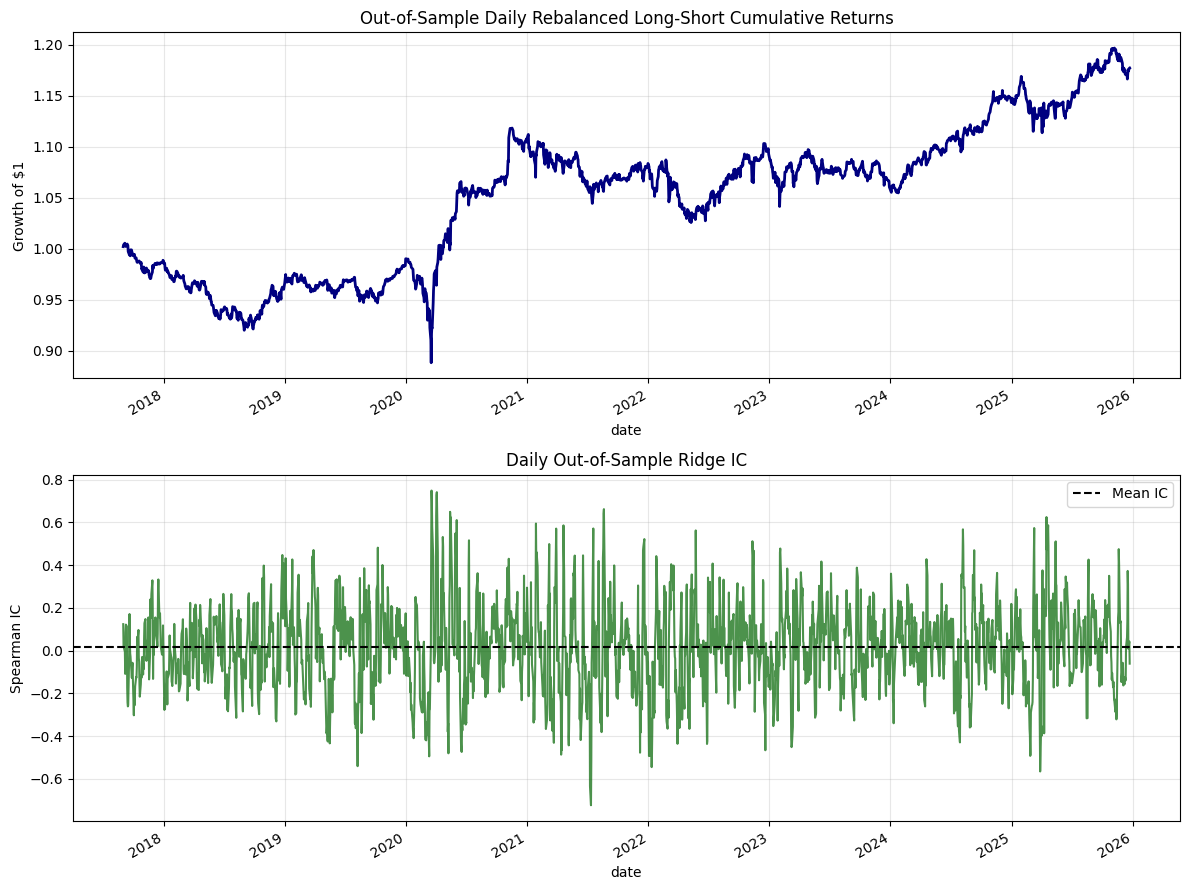

In [41]:
cumulative_returns = (1.0 + portfolio_returns.fillna(0.0)).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=False)

cumulative_returns.plot(ax=axes[0], color="navy", lw=2)
axes[0].set_title("Out-of-Sample Daily Rebalanced Long-Short Cumulative Returns")
axes[0].set_ylabel("Growth of $1")
axes[0].grid(True, alpha=0.3)

ridge_ic_series.plot(ax=axes[1], color="darkgreen", alpha=0.7)
axes[1].axhline(ridge_ic_series.mean(), color="black", linestyle="--", lw=1.5, label="Mean IC")
axes[1].set_title("Daily Out-of-Sample Ridge IC")
axes[1].set_ylabel("Spearman IC")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()
